<a href="https://colab.research.google.com/github/YakshilP/LOW_REGRESSION_MODEL/blob/main/LowesForcast_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
from google.colab import userdata

fred_key = userdata.get('FRED_API_KEY')
print("Key loaded:", fred_key is not None)

Key loaded: True


In [134]:
import requests

headers = {'User-Agent': 'Yakshil Patel yakshilpatel7@gmail.com'}
response = requests.get('https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&company=lowes&type=10-K&dateb=&owner=include&count=10&output=atom', headers=headers)
print(response.status_code)

200


In [135]:
print(response.text[:500])

<?xml version="1.0" encoding="ISO-8859-1" ?>
  <feed xmlns="http://www.w3.org/2005/Atom">
    <author>
      <email>webmaster@sec.gov</email>
      <name>Webmaster</name>
    </author>
    <company-info>
      <addresses>
        <address type="mailing">
          <city>MOORESVILLE</city>
          <state>NC</state>
          <street1>1000 LOWES BLVD.</street1>
          <zip>28117</zip>
        </address>
        <address type="business">
          <city>MOORESVILLE</city>
          <phone>704-


In [136]:
import requests

headers = {'User-Agent': 'Yakshil Patel yakshilpatel7@gmail.com'}
cik = "0000060667"

url = f"https://data.sec.gov/submissions/CIK{cik}.json"
response = requests.get(url, headers=headers)
print(response.status_code)

200


In [137]:
data = response.json()
print(data.keys())

dict_keys(['cik', 'entityType', 'sic', 'sicDescription', 'ownerOrg', 'insiderTransactionForOwnerExists', 'insiderTransactionForIssuerExists', 'name', 'tickers', 'exchanges', 'ein', 'lei', 'description', 'website', 'investorWebsite', 'category', 'fiscalYearEnd', 'stateOfIncorporation', 'stateOfIncorporationDescription', 'addresses', 'phone', 'flags', 'formerNames', 'filings'])


In [138]:
print(data['name'])
print(data['sicDescription'])
print(data['fiscalYearEnd'])


LOWES COMPANIES INC
Retail-Lumber & Other Building Materials Dealers
0131


In [139]:
facts_url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
facts_response = requests.get(facts_url, headers=headers)
print(facts_response.status_code)

facts_data = facts_response.json()
print(facts_data['facts'].keys())

200
dict_keys(['dei', 'us-gaap', 'srt', 'ecd', 'ffd'])


In [140]:
gaap = facts_data['facts']['us-gaap']

# check if the modern revenue tag exists
if 'RevenueFromContractWithCustomerExcludingAssessedTax' in gaap:
    print("Found: RevenueFromContractWithCustomerExcludingAssessedTax")
else:
    print("Not found under that name")

# also check the older, simpler tag
if 'Revenues' in gaap:
    print("Found: Revenues")
else:
    print("Not found under that name either")

Found: RevenueFromContractWithCustomerExcludingAssessedTax
Not found under that name either


In [141]:
revenue_data = gaap['RevenueFromContractWithCustomerExcludingAssessedTax']
print(revenue_data.keys())
print(revenue_data['units'].keys())

dict_keys(['label', 'description', 'units'])
dict_keys(['USD'])


In [142]:
usd_data = revenue_data['units']['USD']
print(len(usd_data))
usd_data[0]


108


{'start': '2016-01-30',
 'end': '2017-02-03',
 'val': 65017000000,
 'accn': '0000060667-19-000042',
 'fy': 2018,
 'fp': 'FY',
 'form': '10-K',
 'filed': '2019-04-02',
 'frame': 'CY2016'}

In [143]:
for entry in usd_data:
    if entry['fp'] != 'FY':
        print(entry)
        break

{'start': '2017-02-04', 'end': '2017-08-04', 'val': 36355000000, 'accn': '0000060667-18-000157', 'fy': 2018, 'fp': 'Q2', 'form': '10-Q', 'filed': '2018-09-04'}


In [144]:
from datetime import datetime

for entry in usd_data:
    start = datetime.strptime(entry['start'], '%Y-%m-%d')
    end = datetime.strptime(entry['end'], '%Y-%m-%d')
    days = (end - start).days
    if 80 <= days <= 100:
        print(entry, "| days:", days)
        break

{'start': '2017-05-06', 'end': '2017-08-04', 'val': 19495000000, 'accn': '0000060667-18-000157', 'fy': 2018, 'fp': 'Q2', 'form': '10-Q', 'filed': '2018-09-04', 'frame': 'CY2017Q2'} | days: 90


In [145]:
quarterly_entries = []

for entry in usd_data:
    start = datetime.strptime(entry['start'], '%Y-%m-%d')
    end = datetime.strptime(entry['end'], '%Y-%m-%d')
    days = (end - start).days
    if 80 <= days <= 100:
        quarterly_entries.append(entry)

print(len(quarterly_entries))

50


In [146]:
import pandas as pd

revenue_df = pd.DataFrame(quarterly_entries)
revenue_df = revenue_df[['end', 'val', 'frame']]
revenue_df = revenue_df.sort_values('end').reset_index(drop=True)
revenue_df.head(10)

,end,val,frame
0,2017-08-04,19495000000,CY2017Q2
1,2017-11-03,16770000000,CY2017Q3
2,2018-05-04,17360000000,CY2018Q1
3,2018-08-03,20888000000,NaN
4,2018-08-03,20888000000,CY2018Q2
5,2018-11-02,17415000000,NaN
6,2018-11-02,17415000000,CY2018Q3
7,2019-05-03,17741000000,NaN
8,2019-05-03,17741000000,CY2019Q1
9,2019-08-02,20992000000,NaN


In [147]:
revenue_df = revenue_df.drop_duplicates(subset=['end', 'val'])
revenue_df = revenue_df.sort_values('end').reset_index(drop=True)
print(len(revenue_df))
revenue_df.head(10)

28


,end,val,frame
0,2017-08-04,19495000000,CY2017Q2
1,2017-11-03,16770000000,CY2017Q3
2,2018-05-04,17360000000,CY2018Q1
3,2018-08-03,20888000000,NaN
4,2018-11-02,17415000000,NaN
5,2019-05-03,17741000000,NaN
6,2019-08-02,20992000000,NaN
7,2019-11-01,17388000000,CY2019Q3
8,2020-05-01,19675000000,NaN
9,2020-07-31,27302000000,NaN


In [148]:
print(revenue_df['end'].min())
print(revenue_df['end'].max())

2017-08-04
2026-07-31


In [149]:
mortgage_url = f"https://api.stlouisfed.org/fred/series/observations?series_id=MORTGAGE30US&api_key={fred_key}&file_type=json"
mortgage_response = requests.get(mortgage_url)
print(mortgage_response.status_code)

mortgage_data = mortgage_response.json()
print(mortgage_data.keys())

200
dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])


In [150]:
print(mortgage_data['count'])
mortgage_data['observations'][0]

2892


{'realtime_start': '2026-08-27',
 'realtime_end': '2026-08-27',
 'date': '1971-04-02',
 'value': '7.33'}

In [151]:
mortgage_df = pd.DataFrame(mortgage_data['observations'])
mortgage_df = mortgage_df[['date', 'value']]
mortgage_df['value'] = mortgage_df['value'].astype(float)
mortgage_df['date'] = pd.to_datetime(mortgage_df['date'])

mortgage_df = mortgage_df[mortgage_df['date'] >= '2017-01-01']
mortgage_df = mortgage_df.reset_index(drop=True)

print(len(mortgage_df))
mortgage_df.head()

504


,date,value
0,2017-01-05,4.20
1,2017-01-12,4.12
2,2017-01-19,4.09
3,2017-01-26,4.19
4,2017-02-02,4.19


In [152]:
revenue_df['end'] = pd.to_datetime(revenue_df['end'])
revenue_df['quarter_start'] = revenue_df['end'] - pd.Timedelta(days=90)

avg_mortgage_rates = []

for i, row in revenue_df.iterrows():
    mask = (mortgage_df['date'] >= row['quarter_start']) & (mortgage_df['date'] <= row['end'])
    quarter_rates = mortgage_df[mask]['value']
    avg_rate = quarter_rates.mean()
    avg_mortgage_rates.append(avg_rate)

revenue_df['avg_mortgage_rate'] = avg_mortgage_rates
revenue_df[['end', 'val', 'avg_mortgage_rate']].head(10)

,end,val,avg_mortgage_rate
0,2017-08-04,19495000000,3.949231
1,2017-11-03,16770000000,3.862308
2,2018-05-04,17360000000,4.441538
3,2018-08-03,20888000000,4.566923
4,2018-11-02,17415000000,4.677692
5,2019-05-03,17741000000,4.250000
6,2019-08-02,20992000000,3.864615
7,2019-11-01,17388000000,3.630000
8,2020-05-01,19675000000,3.399231
9,2020-07-31,27302000000,3.127692


In [153]:
housing_url = f"https://api.stlouisfed.org/fred/series/observations?series_id=HOUST&api_key={fred_key}&file_type=json"
housing_response = requests.get(housing_url)
print(housing_response.status_code)

housing_data = housing_response.json()
print(housing_data['count'])
housing_data['observations'][0]

200
811


{'realtime_start': '2026-08-18',
 'realtime_end': '2026-08-18',
 'date': '1959-01-01',
 'value': '1657'}

In [154]:
housing_df = pd.DataFrame(housing_data['observations'])
housing_df = housing_df[['date', 'value']]
housing_df['value'] = housing_df['value'].astype(float)
housing_df['date'] = pd.to_datetime(housing_df['date'])
housing_df = housing_df[housing_df['date'] >= '2017-01-01']
housing_df = housing_df.reset_index(drop=True)

print(len(housing_df))
housing_df.head()

115


,date,value
0,2017-01-01,1190.0
1,2017-02-01,1271.0
2,2017-03-01,1190.0
3,2017-04-01,1146.0
4,2017-05-01,1157.0


In [155]:
avg_housing_starts = []

for i, row in revenue_df.iterrows():
    mask = (housing_df['date'] >= row['quarter_start']) & (housing_df['date'] <= row['end'])
    quarter_housing = housing_df[mask]['value']
    avg_housing = quarter_housing.mean()
    avg_housing_starts.append(avg_housing)

revenue_df['avg_housing_starts'] = avg_housing_starts
revenue_df[['end', 'val', 'avg_mortgage_rate', 'avg_housing_starts']].head(10)

,end,val,avg_mortgage_rate,avg_housing_starts
0,2017-08-04,19495000000,3.949231,1204.666667
1,2017-11-03,16770000000,3.862308,1237.000000
2,2018-05-04,17360000000,4.441538,1317.000000
3,2018-08-03,20888000000,4.566923,1229.333333
4,2018-11-02,17415000000,4.677692,1217.333333
5,2019-05-03,17741000000,4.250000,1252.000000
6,2019-08-02,20992000000,3.864615,1286.000000
7,2019-11-01,17388000000,3.630000,1329.666667
8,2020-05-01,19675000000,3.399231,1197.500000
9,2020-07-31,27302000000,3.127692,1396.000000


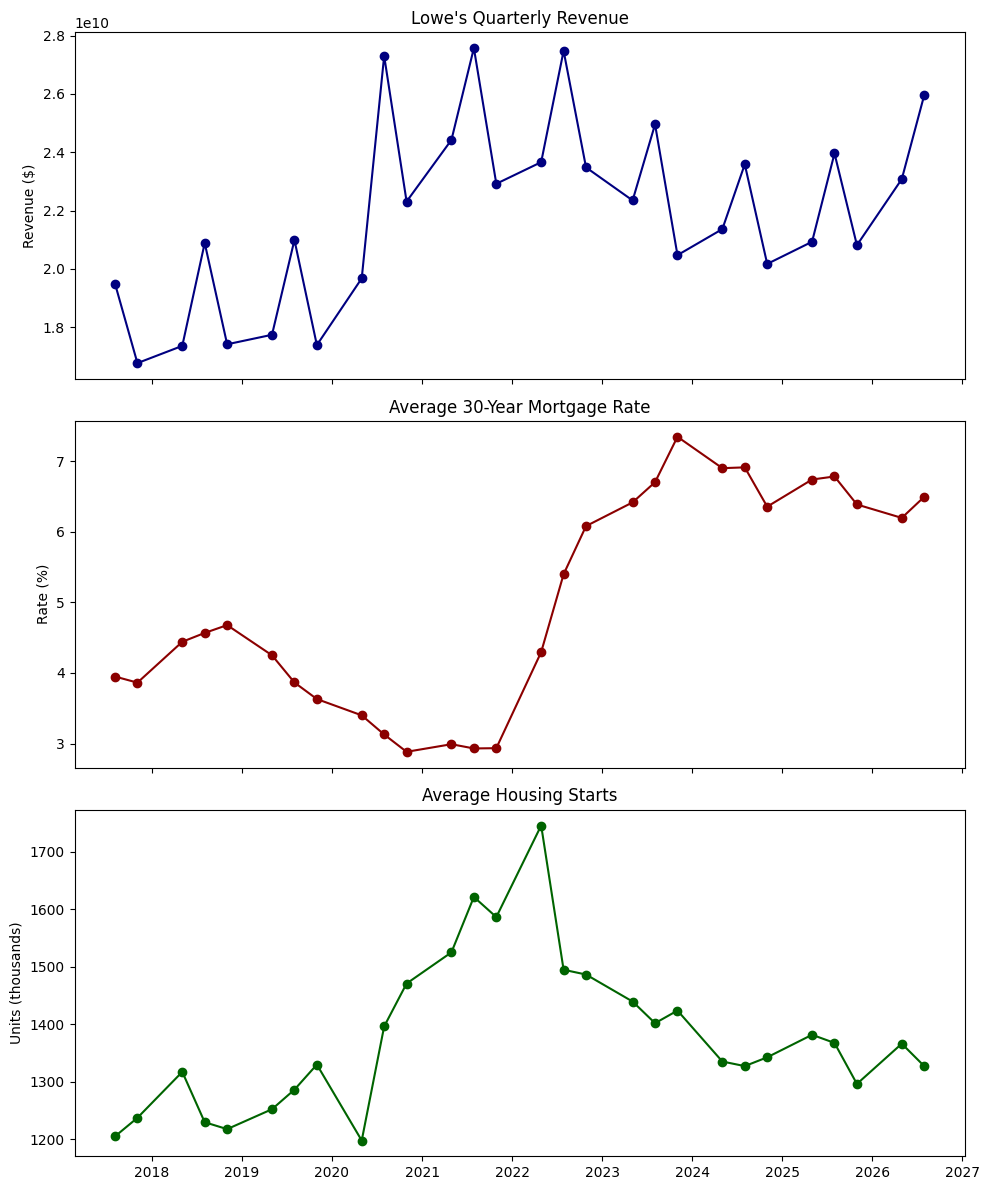

In [156]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(revenue_df['end'], revenue_df['val'], marker='o', color='navy')
axes[0].set_title("Lowe's Quarterly Revenue")
axes[0].set_ylabel("Revenue ($)")

axes[1].plot(revenue_df['end'], revenue_df['avg_mortgage_rate'], marker='o', color='darkred')
axes[1].set_title("Average 30-Year Mortgage Rate")
axes[1].set_ylabel("Rate (%)")

axes[2].plot(revenue_df['end'], revenue_df['avg_housing_starts'], marker='o', color='darkgreen')
axes[2].set_title("Average Housing Starts")
axes[2].set_ylabel("Units (thousands)")

plt.tight_layout()
plt.show()

In [157]:
from google.colab import userdata
fred_key = userdata.get('FRED_API_KEY')
print("Key loaded:", fred_key is not None)


Key loaded: True


In [158]:
sentiment_url = f"https://api.stlouisfed.org/fred/series/observations?series_id=UMCSENT&api_key={fred_key}&file_type=json"
sentiment_response = requests.get(sentiment_url)
print(sentiment_response.status_code)

sentiment_data = sentiment_response.json()
print(sentiment_data['count'])
sentiment_data['observations'][0]

200
885


{'realtime_start': '2026-08-28',
 'realtime_end': '2026-08-28',
 'date': '1952-11-01',
 'value': '86.2'}

In [159]:
sentiment_df = pd.DataFrame(sentiment_data['observations'])
sentiment_df = sentiment_df[['date', 'value']]
sentiment_df = sentiment_df[sentiment_df['value'] != '.']
sentiment_df['value'] = sentiment_df['value'].astype(float)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df = sentiment_df[sentiment_df['date'] >= '2017-01-01']
sentiment_df = sentiment_df.reset_index(drop=True)

print(len(sentiment_df))
sentiment_df.head()

115


,date,value
0,2017-01-01,98.5
1,2017-02-01,96.3
2,2017-03-01,96.9
3,2017-04-01,97.0
4,2017-05-01,97.1


In [160]:
avg_sentiment = []

for i, row in revenue_df.iterrows():
    mask = (sentiment_df['date'] >= row['quarter_start']) & (sentiment_df['date'] <= row['end'])
    quarter_sentiment = sentiment_df[mask]['value']
    avg_sent = quarter_sentiment.mean()
    avg_sentiment.append(avg_sent)

In [161]:
avg_sentiment = []

for i, row in revenue_df.iterrows():
    mask = (sentiment_df['date'] >= row['quarter_start']) & (sentiment_df['date'] <= row['end'])
    quarter_sentiment = sentiment_df[mask]['value']
    avg_sent = quarter_sentiment.mean()
    avg_sentiment.append(avg_sent)

revenue_df['avg_sentiment'] = avg_sentiment
print("Column added. Columns now:", revenue_df.columns.tolist())


Column added. Columns now: ['end', 'val', 'frame', 'quarter_start', 'avg_mortgage_rate', 'avg_housing_starts', 'avg_sentiment']


In [162]:
print(revenue_df[['end', 'val', 'avg_mortgage_rate', 'avg_housing_starts', 'avg_sentiment']].head(10))


         end          val  avg_mortgage_rate  avg_housing_starts  \
0 2017-08-04  19495000000           3.949231         1204.666667   
1 2017-11-03  16770000000           3.862308         1237.000000   
2 2018-05-04  17360000000           4.441538         1317.000000   
3 2018-08-03  20888000000           4.566923         1229.333333   
4 2018-11-02  17415000000           4.677692         1217.333333   
5 2019-05-03  17741000000           4.250000         1252.000000   
6 2019-08-02  20992000000           3.864615         1286.000000   
7 2019-11-01  17388000000           3.630000         1329.666667   
8 2020-05-01  19675000000           3.399231         1197.500000   
9 2020-07-31  27302000000           3.127692         1396.000000   

   avg_sentiment  
0      95.066667  
1      98.100000  
2      99.400000  
3      97.433333  
4      98.733333  
5      98.533333  
6      95.466667  
7      95.166667  
8      83.550000  
9      75.300000  


In [163]:
import yfinance as yf


low = yf.Ticker("LOW").history(period="10y")
low = low.reset_index()
low['Date'] = pd.to_datetime(low['Date']).dt.tz_localize(None)

print(low.shape)
low.head()

(2511, 8)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2016-09-06,63.733547,63.824726,62.631118,63.004124,4779700,0.0,0.0
1,2016-09-07,62.970986,62.995851,62.175249,62.531673,5481100,0.0,0.0
2,2016-09-08,61.810535,62.216690,61.271753,61.445820,7495400,0.0,0.0
3,2016-09-09,60.956768,61.147409,59.489624,59.489624,7632800,0.0,0.0
4,2016-09-12,59.017167,60.227356,58.735347,60.094730,6165800,0.0,0.0


In [164]:
low['Price_Change'] = low['Close'].diff()
low['Direction'] = (low['Price_Change'] > 0).astype(int)

low[['Date', 'Close', 'Price_Change', 'Direction']].head(10)

,Date,Close,Price_Change,Direction
0,2016-09-06,63.004124,NaN,0
1,2016-09-07,62.531673,-0.472450,0
2,2016-09-08,61.445820,-1.085854,0
3,2016-09-09,59.489624,-1.956196,0
4,2016-09-12,60.094730,0.605106,1
5,2016-09-13,58.917671,-1.177059,0
6,2016-09-14,58.950829,0.033157,1
7,2016-09-15,59.108334,0.157505,1
8,2016-09-16,58.809925,-0.298409,0
9,2016-09-19,59.108334,0.298409,1


In [165]:
quarterly_direction = []

for i, row in revenue_df.iterrows():
    mask = (low['Date'] >= row['quarter_start']) & (low['Date'] <= row['end'])
    quarter_prices = low[mask]['Close']

    if len(quarter_prices) > 0:
        start_price = quarter_prices.iloc[0]
        end_price = quarter_prices.iloc[-1]
        direction = 1 if end_price > start_price else 0
    else:
        direction = None

    quarterly_direction.append(direction)

revenue_df['stock_direction'] = quarterly_direction
print(revenue_df[['end', 'val', 'stock_direction']].head(10))

         end          val  stock_direction
0 2017-08-04  19495000000                0
1 2017-11-03  16770000000                0
2 2018-05-04  17360000000                0
3 2018-08-03  20888000000                1
4 2018-11-02  17415000000                0
5 2019-05-03  17741000000                1
6 2019-08-02  20992000000                0
7 2019-11-01  17388000000                1
8 2020-05-01  19675000000                0
9 2020-07-31  27302000000                1


In [166]:
print(revenue_df['stock_direction'].value_counts())

stock_direction
0    14
1    14
Name: count, dtype: int64


In [167]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

features = ['avg_mortgage_rate', 'avg_housing_starts', 'avg_sentiment']
X = revenue_df[features]
y = revenue_df['val']

print(X.shape, y.shape)
X.head()

(28, 3) (28,)


,avg_mortgage_rate,avg_housing_starts,avg_sentiment
0,3.949231,1204.666667,95.066667
1,3.862308,1237.000000,98.100000
2,4.441538,1317.000000,99.400000
3,4.566923,1229.333333,97.433333
4,4.677692,1217.333333,98.733333


In [168]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.71278367 -1.33443611  1.19660015]
 [-0.77072195 -1.08650011  1.38097078]
 [-0.38463766 -0.47305021  1.45998677]
 [-0.30106298 -1.14528906  1.34044976]
 [-0.22723013 -1.23730655  1.41946575]]


In [169]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)

for name, coef in zip(features, ridge.coef_):
    print(f"{name}: {coef:,.2f}")

print(f"Intercept: {ridge.intercept_:,.2f}")

avg_mortgage_rate: -845,232,441.97
avg_housing_starts: 908,268,701.42
avg_sentiment: -1,936,121,724.49
Intercept: 21,946,035,714.29


In [171]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_scaled, y)

for name, coef in zip(features, lasso.coef_):
    print(f"{name}: {coef:,.2f}")

print(f"Intercept: {lasso.intercept_:,.2f}")


avg_mortgage_rate: -1,032,738,431.37
avg_housing_starts: 815,145,424.01
avg_sentiment: -2,165,122,220.49
Intercept: 21,946,035,714.29


In [172]:
lasso_strong = Lasso(alpha=1000000000)
lasso_strong.fit(X_scaled, y)

for name, coef in zip(features, lasso_strong.coef_):
    print(f"{name}: {coef:,.2f}")

avg_mortgage_rate: -0.00
avg_housing_starts: 647,387,126.81
avg_sentiment: -584,731,389.75


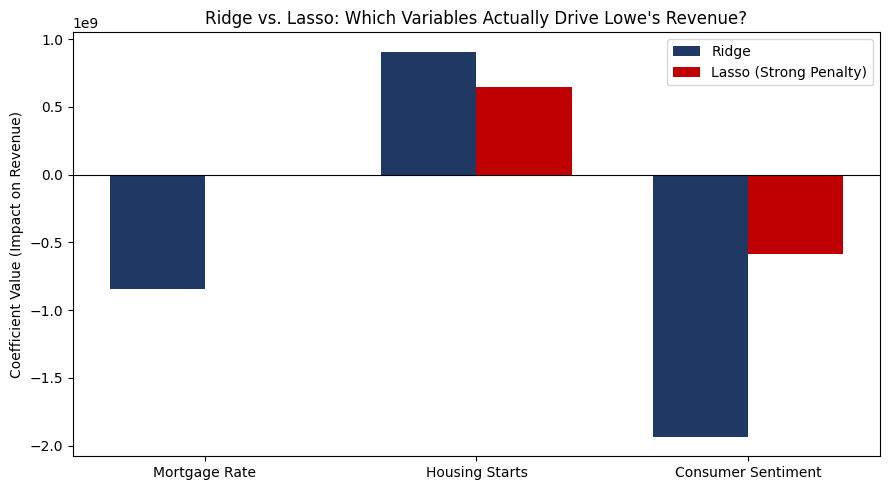

In [174]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, ridge.coef_, width, label='Ridge', color='#1F3864')
ax.bar(x + width/2, lasso_strong.coef_, width, label='Lasso (Strong Penalty)', color='#C00000')

ax.set_ylabel('Coefficient Value (Impact on Revenue)')
ax.set_title('Ridge vs. Lasso: Which Variables Actually Drive Lowe\'s Revenue?')
ax.set_xticks(x)
ax.set_xticklabels(['Mortgage Rate', 'Housing Starts', 'Consumer Sentiment'])
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.savefig('ridge_lasso_comparison.png', dpi=150)
plt.show()

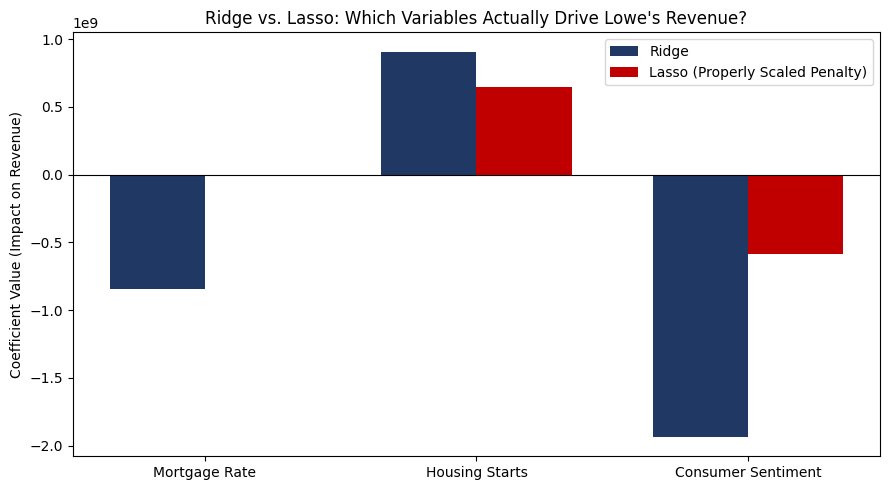

In [175]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, ridge.coef_, width, label='Ridge', color='#1F3864')
ax.bar(x + width/2, lasso_strong.coef_, width, label='Lasso (Properly Scaled Penalty)', color='#C00000')

ax.set_ylabel('Coefficient Value (Impact on Revenue)')
ax.set_title('Ridge vs. Lasso: Which Variables Actually Drive Lowe\'s Revenue?')
ax.set_xticks(x)
ax.set_xticklabels(['Mortgage Rate', 'Housing Starts', 'Consumer Sentiment'])
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.savefig('ridge_lasso_comparison.png', dpi=150)
plt.show()